# Playground for LLMs

Llama 3.2 1B Instruct model

In [ ]:
from src.llm import LLM

model = LLM(model_id="meta-llama/Llama-3.2-1B-Instruct")

prompt = ["What is the capital of Italy?"]
response = model.generate_batch(prompt)

print(response[0][0])

Llama 3.2 70B Chat model with 8-bit quantization

In [ ]:
from src.llm import LLM

model = LLM(model_id="meta-llama/Llama-2-70b-chat-hf")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

In [ ]:
from src.llm import LLM

model = LLM(model_id="google/gemma-3-4b-it")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

In [ ]:
import json 
import random 

with open("./llms.json", 'r') as f:
    available_llms = json.load(f)["llms"]

llms = random.sample(available_llms, 2)
names = [llm["name"] for llm in available_llms]
shortnames = [llm["shortname"] for llm in available_llms]

print(names)
print(shortnames)

In [ ]:
available_llms

In [ ]:
# import os
# import shutil

# def merge_directories(dir1, dir2, output_dir):
#     """
#     Merge two directories into a new one.
#     - All files/dirs from dir1 are copied.
#     - Files from dir2 are copied only if they don't already exist in dir1.
#     - Directories are merged recursively.

#     Args:
#         dir1 (str): Path to the first directory.
#         dir2 (str): Path to the second directory.
#         output_dir (str): Path where the merged directory will be created.
#     """
#     os.makedirs(output_dir, exist_ok=True)

#     # Copy everything from dir1 (takes precedence)
#     for root, _, files in os.walk(dir1):
#         rel_path = os.path.relpath(root, dir1)
#         target_root = os.path.join(output_dir, rel_path)
#         os.makedirs(target_root, exist_ok=True)

#         for file in files:
#             src_file = os.path.join(root, file)
#             dst_file = os.path.join(target_root, file)
#             shutil.copy2(src_file, dst_file)

#     # Copy from dir2 only if not already present
#     for root, _, files in os.walk(dir2):
#         rel_path = os.path.relpath(root, dir2)
#         target_root = os.path.join(output_dir, rel_path)
#         os.makedirs(target_root, exist_ok=True)

#         for file in files:
#             dst_file = os.path.join(target_root, file)
#             if not os.path.exists(dst_file):  # keep dir1’s version if conflict
#                 src_file = os.path.join(root, file)
#                 shutil.copy2(src_file, dst_file)

#     print(f"Merged contents into: {output_dir}")
    
# merge_directories("./logs/", "./tmp/logs/", "./lepedro/")

In [ ]:
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
import re
from collections import defaultdict
from pathlib import Path


def sample(dict: dict, n: int) -> dict:
    if not dict:
        return dict
    
    # Keys and weights
    elements = np.array(list(dict.keys()))
    weights = np.array(list(dict.values()), dtype=float)

    # Normalize weights to probabilities
    probabilities = weights / weights.sum()

    # Sample with replacement
    samples = np.random.choice(elements, size=n, p=probabilities)

    # Count occurrences and convert back to dictionary
    sampled_dict = {
        str(key): int(count) for key, count in zip(*np.unique(samples, return_counts=True))
    }

    return sampled_dict

def get_family(model_name):
    return model_name.split("/")[1] if model_name.startswith("/") else model_name.split("/")[0]

def get_color(model_name, models_in_family):
    family = get_family(model_name)
    cmap = family_colormaps[family]
    idx = models_in_family.index(model_name)
    n = len(models_in_family)
    return cmap(0.3 + 0.6 * idx / (n - 1 if n > 1 else 1))  # spaced shades

def get_available_models(model_names, required_files):
    working_model_names = []
    corrupted_model_names = {}
    required = set(required_files)
    for m in model_names:
        files = set(glob.glob(f"./results{m}/*"))
        files = set([f.split('/')[-1] for f in files])
        missing_files = required.difference(files)
        if missing_files != set():
            corrupted_model_names[m] = required.difference(files)
        else:
            working_model_names.append(m)
            
    return working_model_names

# Define families and assign colormaps
family_colormaps = {
    "meta-llama": cm.Blues,
    "google": cm.Reds,
    "microsoft": cm.Greens,
    "Qwen": cm.Purples,
    "deepseek-ai": cm.Oranges,
}

# Files required to run all the experiments
required_files = [
    "amsterdam_problem-coordinate.jsonl",
    "amsterdam_problem-guess.jsonl",
    "amsterdam_problem-pick.jsonl",
    "nottingham_problem-coordinate.jsonl",
    "nottingham_problem-guess.jsonl",
    "nottingham_problem-pick.jsonl"
]

# Families of models we test: each corresponds to a folder in ./results
models = ["meta-llama"]
num_samples = 64

# Datasets and tasks (we name them labels)
dataset_names = ["amsterdam", "nottingham"]
labels = ["pick", "guess", "coordinate"]

# Matplotlib config
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Times New Roman'

# Savedir (creation)
SAVEDIR = "./plots"
COORDINATION_INDEX_FOLDER = "/coordination-index/sample/llama"
BEST_MODELS_COORDINATION_INDEX_FOLDER = "/coordination-index-best/sample/llama"
BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER = "/coordination-index-best-merge/sample/llama"
BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER_SIDE = "/coordination-index-best-merge-side/sample/llama"


for folder in [COORDINATION_INDEX_FOLDER, 
               BEST_MODELS_COORDINATION_INDEX_FOLDER,
               BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER,
               BEST_MODELS_COORDINATION_INDEX_SAMPLING_FOLDER_SIDE]:
    if not os.path.exists(Path(SAVEDIR + folder)):
        print("Creating path: ", Path(SAVEDIR + folder))
        os.makedirs(Path(SAVEDIR + folder))
    
if __name__ == "__main__":

    # Collect the names of the folders inside each "model"
    model_names = []
    for m in models:
        for model_path in next(os.walk("./results/" + m)):
            if "./results/" in model_path:
                prefix = model_path
                continue
            model_names.extend([prefix.split("./results")[1] + "/" + llm for llm in model_path])

    print("--- Available Models ---")
    for i,m in enumerate(model_names):
        print(f"{i+1}. {m}")
        
    model_names = get_available_models(model_names, required_files)
    
    # Sort by model-size
    model_by_size = {}
    for m in model_names:
        match = re.search(r"-([0-9]+)([B])(?:-|$)", m, re.DOTALL)
        size = int(match.group(1).strip())
        model_by_size[m] = size
    
    model_by_size = {k: v for k, v in sorted(model_by_size.items(), key=lambda item: item[1])}
    model_names = list(model_by_size.keys())

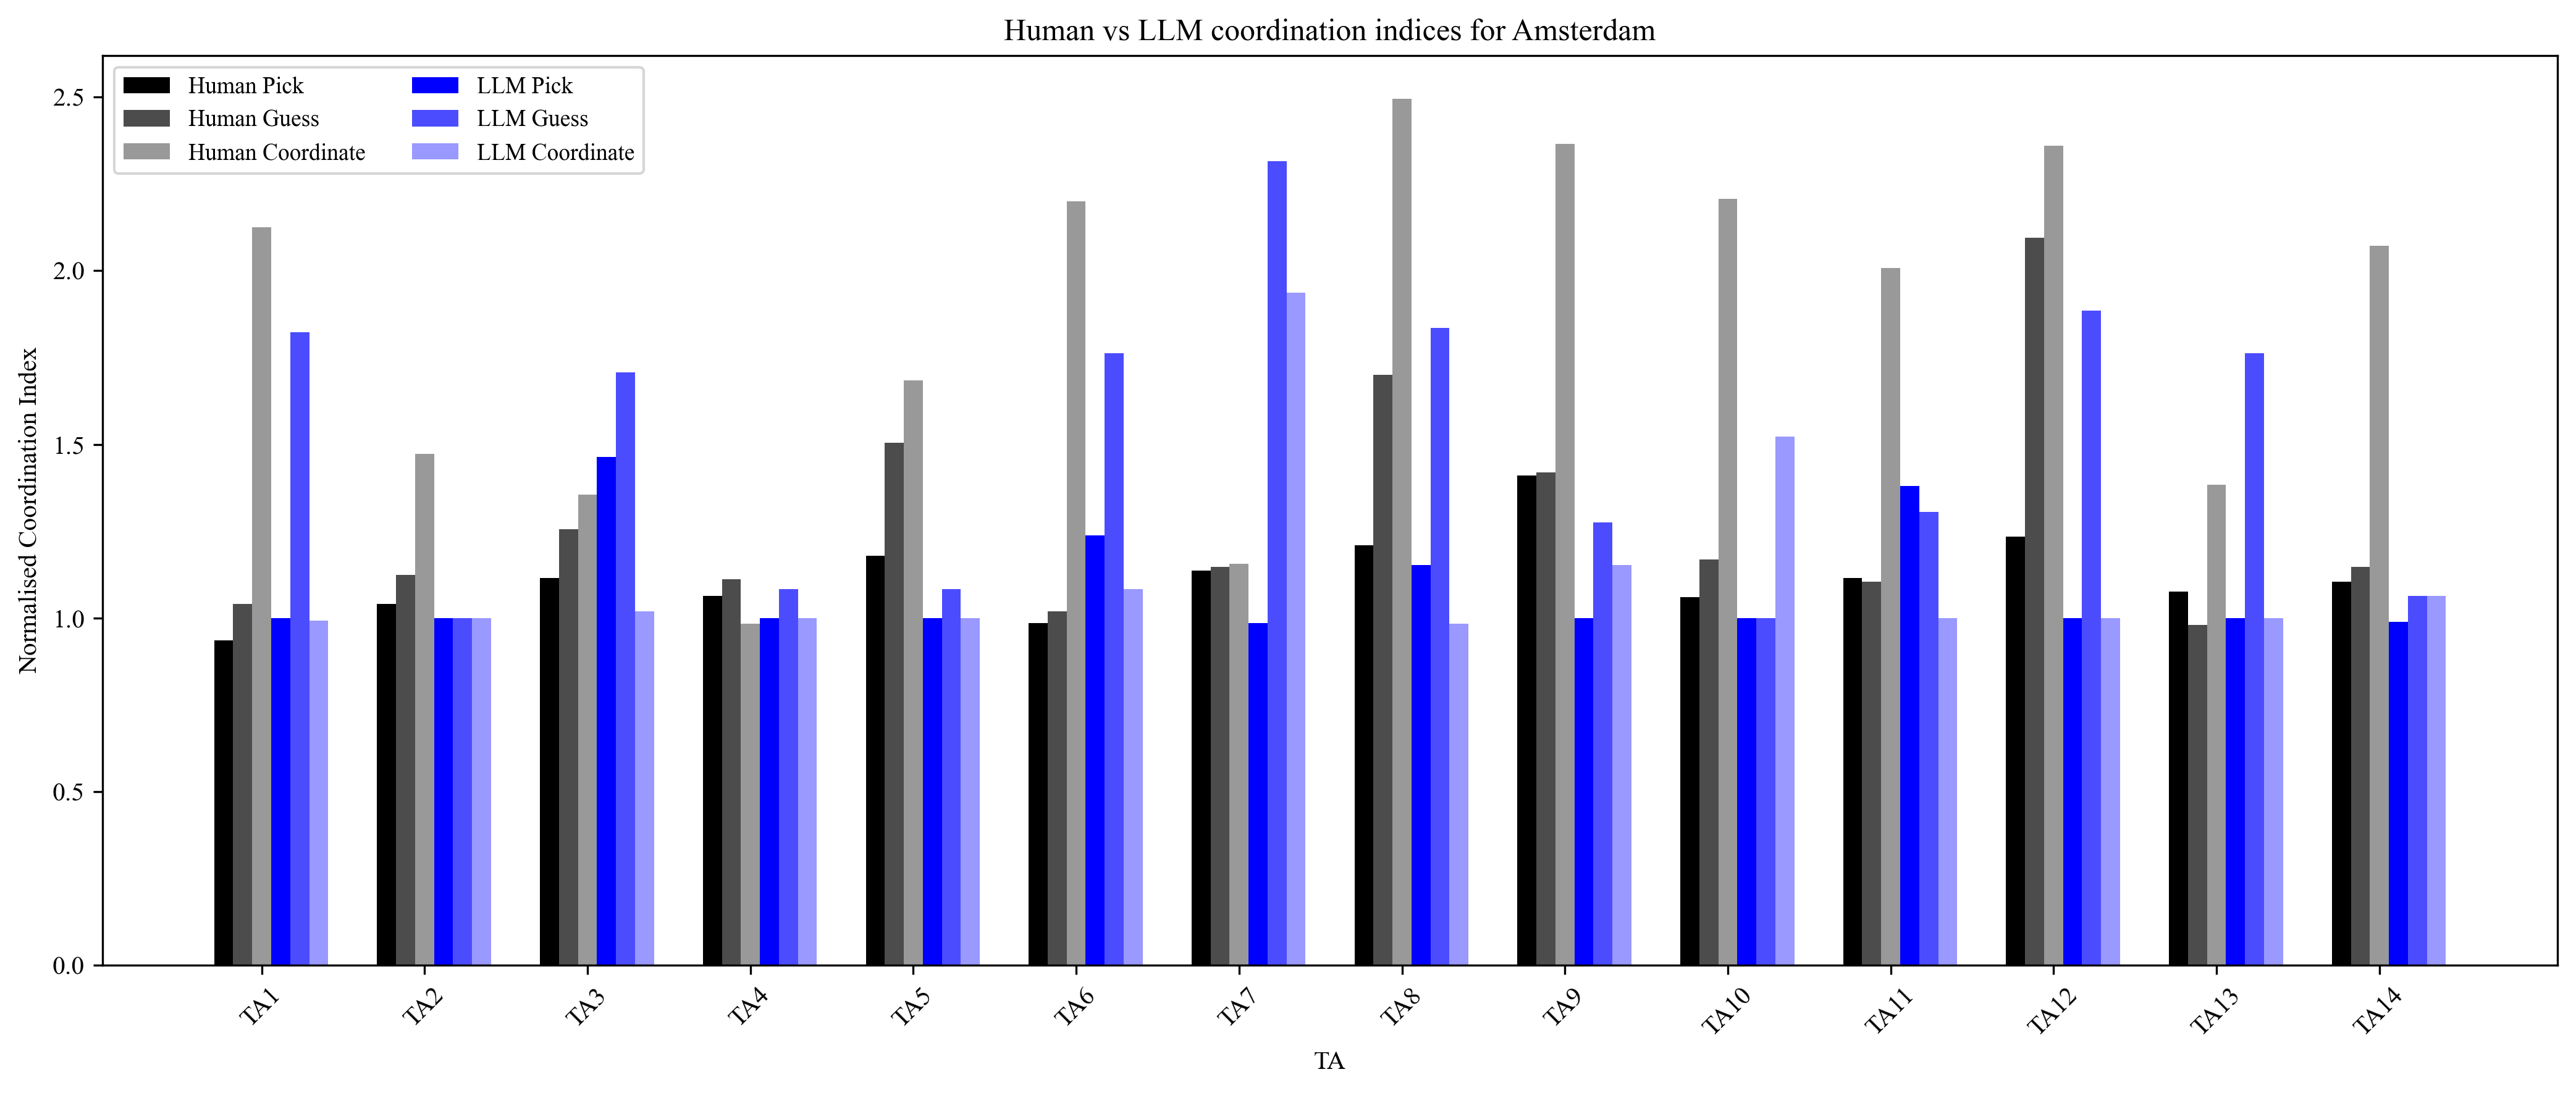

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Human data
human_data = {'TA1': {'pick': 0.935, 'guess': 1.04, 'coordinate': 2.125},
              'TA2': {'pick': 1.04, 'guess': 1.124, 'coordinate': 1.472},
              'TA3': {'pick': 1.115, 'guess': 1.255, 'coordinate': 1.355},
              'TA4': {'pick': 1.064, 'guess': 1.112, 'coordinate': 0.984},
              'TA5': {'pick': 1.18, 'guess': 1.504, 'coordinate': 1.684},
              'TA6': {'pick': 0.985, 'guess': 1.02, 'coordinate': 2.2},
              'TA7': {'pick': 1.136, 'guess': 1.148, 'coordinate': 1.156},
              'TA8': {'pick': 1.21, 'guess': 1.7, 'coordinate': 2.495},
              'TA9': {'pick': 1.41, 'guess': 1.42, 'coordinate': 2.365},
              'TA10': {'pick': 1.06, 'guess': 1.168, 'coordinate': 2.208},
              'TA11': {'pick': 1.116, 'guess': 1.104, 'coordinate': 2.008},
              'TA12': {'pick': 1.235, 'guess': 2.095, 'coordinate': 2.36},
              'TA13': {'pick': 1.076, 'guess': 0.98, 'coordinate': 1.384},
              'TA14': {'pick': 1.104, 'guess': 1.148, 'coordinate': 2.072}}

# LLM data
llm_data = {'TA1': {'pick': 1.0, 'guess': 1.8229, 'coordinate': 0.9931},
            'TA2': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TA3': {'pick': 1.4643, 'guess': 1.7073, 'coordinate': 1.0198},
            'TA4': {'pick': 1.0, 'guess': 1.0833, 'coordinate': 1.0},
            'TA5': {'pick': 1.0, 'guess': 1.0833, 'coordinate': 1.0},
            'TA6': {'pick': 1.2381, 'guess': 1.7619, 'coordinate': 1.0833},
            'TA7': {'pick': 0.9851, 'guess': 2.3155, 'coordinate': 1.9375},
            'TA8': {'pick': 1.1518, 'guess': 1.8353, 'coordinate': 0.9841},
            'TA9': {'pick': 1.0, 'guess': 1.2753, 'coordinate': 1.1518},
            'TA10': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.5223},
            'TA11': {'pick': 1.38095, 'guess': 1.3056, 'coordinate': 1.0},
            'TA12': {'pick': 1.0, 'guess': 1.8854, 'coordinate': 1.0},
            'TA13': {'pick': 1.0, 'guess': 1.7619, 'coordinate': 1.0},
            'TA14': {'pick': 0.9881, 'guess': 1.0645, 'coordinate': 1.0645}}

TAs = list(human_data.keys())
tasks = ['pick', 'guess', 'coordinate']

x = np.arange(len(TAs))  # the label locations
width = 0.35  # width of bar group

fig, ax = plt.subplots(figsize=(14,6))

# Human bars (black)
human_vals = np.array([[human_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x - width/2, human_vals[:,0], width/3, color='black', label='Human Pick')
ax.bar(x - width/2 + width/3, human_vals[:,1], width/3, color='black', alpha=0.7, label='Human Guess')
ax.bar(x - width/2 + 2*width/3, human_vals[:,2], width/3, color='black', alpha=0.4, label='Human Coordinate')

# LLM bars (blue)
llm_vals = np.array([[llm_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x + width/2, llm_vals[:,0], width/3, color='blue', label='LLM Pick')
ax.bar(x + width/2 + width/3, llm_vals[:,1], width/3, color='blue', alpha=0.7, label='LLM Guess')
ax.bar(x + width/2 + 2*width/3, llm_vals[:,2], width/3, color='blue', alpha=0.4, label='LLM Coordinate')

# Labels and formatting
ax.set_ylabel('Normalised Coordination Index')
ax.set_xlabel('TA')
ax.set_title('Human vs LLM coordination indices for Amsterdam')
ax.set_xticks(x + width/6)
ax.set_xticklabels(TAs)
ax.legend(ncol=2, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


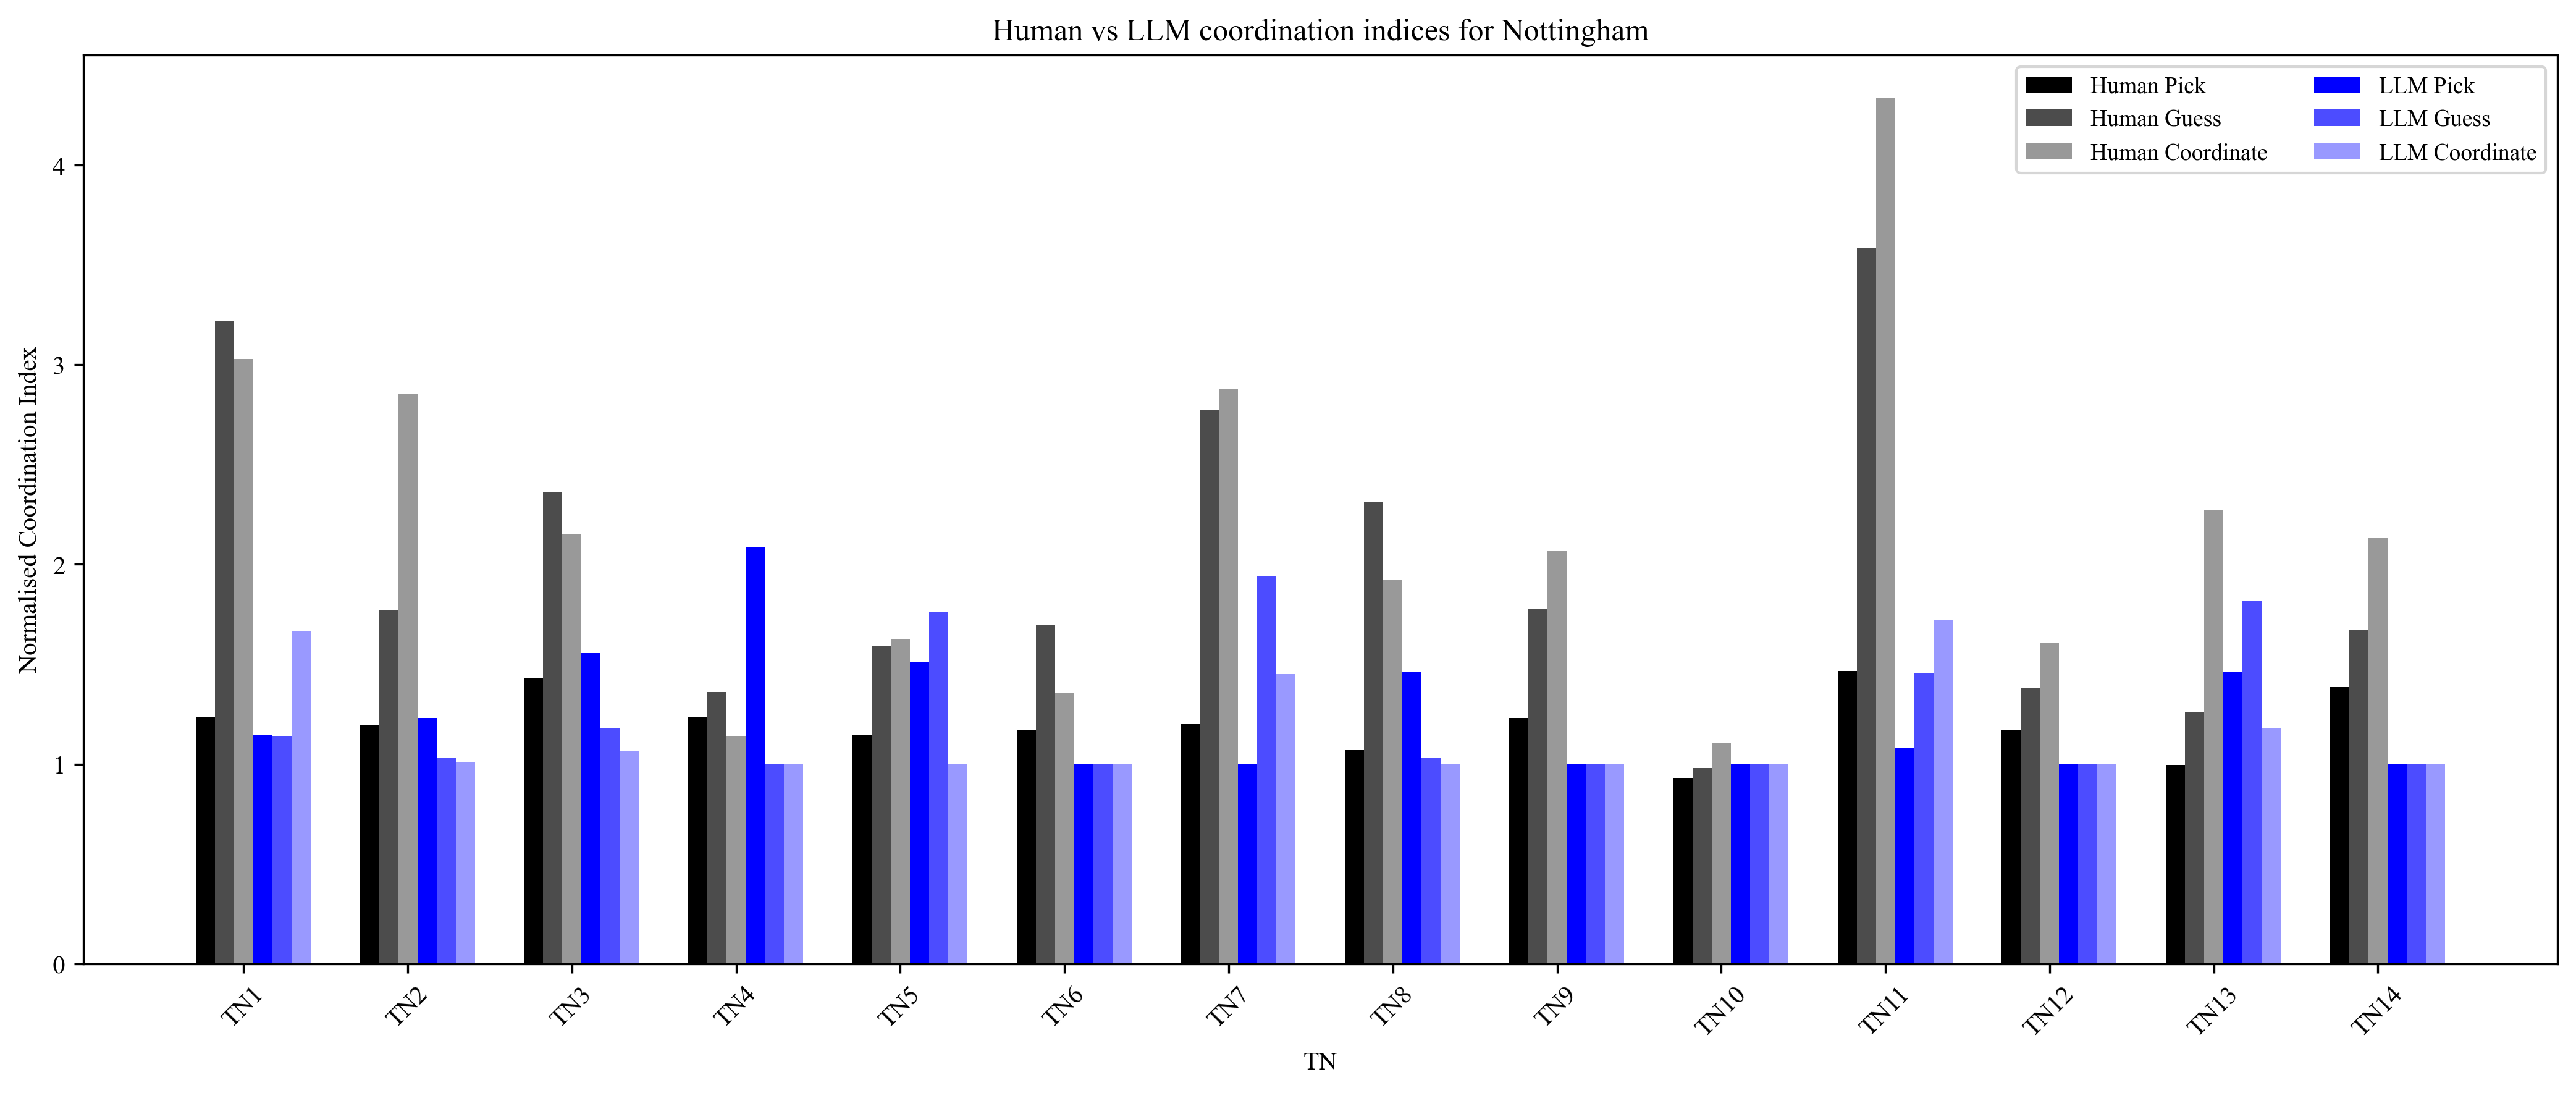

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Human data for Nottingham
human_data = {'TN1': {'pick': 1.235, 'guess': 3.22, 'coordinate': 3.03},
              'TN2': {'pick': 1.195, 'guess': 1.77, 'coordinate': 2.855},
              'TN3': {'pick': 1.43, 'guess': 2.36, 'coordinate': 2.15},
              'TN4': {'pick': 1.235, 'guess': 1.36, 'coordinate': 1.1425},
              'TN5': {'pick': 1.145, 'guess': 1.59, 'coordinate': 1.625},
              'TN6': {'pick': 1.17, 'guess': 1.695, 'coordinate': 1.355},
              'TN7': {'pick': 1.2, 'guess': 2.775, 'coordinate': 2.88},
              'TN8': {'pick': 1.07, 'guess': 2.315, 'coordinate': 1.92},
              'TN9': {'pick': 1.23, 'guess': 1.78, 'coordinate': 2.065},
              'TN10': {'pick': 0.93, 'guess': 0.98, 'coordinate': 1.105},
              'TN11': {'pick': 1.465, 'guess': 3.585, 'coordinate': 4.335},
              'TN12': {'pick': 1.17, 'guess': 1.38, 'coordinate': 1.61},
              'TN13': {'pick': 0.995, 'guess': 1.26, 'coordinate': 2.275},
              'TN14': {'pick': 1.385, 'guess': 1.675, 'coordinate': 2.13}}

# LLM data for Nottingham
llm_data = {'TN1': {'pick': 1.144841, 'guess': 1.136905, 'coordinate': 1.662698},
            'TN2': {'pick': 1.232143, 'guess': 1.032738, 'coordinate': 1.008929},
            'TN3': {'pick': 1.555556, 'guess': 1.178571, 'coordinate': 1.064484},
            'TN4': {'pick': 2.087798, 'guess': 1.0, 'coordinate': 1.0},
            'TN5': {'pick': 1.508929, 'guess': 1.761905, 'coordinate': 1.0},
            'TN6': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN7': {'pick': 1.0, 'guess': 1.938988, 'coordinate': 1.450893},
            'TN8': {'pick': 1.464286, 'guess': 1.032738, 'coordinate': 1.0},
            'TN9': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN10': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN11': {'pick': 1.083333, 'guess': 1.458333, 'coordinate': 1.721726},
            'TN12': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0},
            'TN13': {'pick': 1.464286, 'guess': 1.818452, 'coordinate': 1.178571},
            'TN14': {'pick': 1.0, 'guess': 1.0, 'coordinate': 1.0}}

TAs = list(human_data.keys())
tasks = ['pick', 'guess', 'coordinate']

x = np.arange(len(TAs))  # the label locations
width = 0.35  # width of bar group

fig, ax = plt.subplots(figsize=(14,6))

# Human bars (black)
human_vals = np.array([[human_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x - width/2, human_vals[:,0], width/3, color='black', label='Human Pick')
ax.bar(x - width/2 + width/3, human_vals[:,1], width/3, color='black', alpha=0.7, label='Human Guess')
ax.bar(x - width/2 + 2*width/3, human_vals[:,2], width/3, color='black', alpha=0.4, label='Human Coordinate')

# LLM bars (blue)
llm_vals = np.array([[llm_data[ta][task] for task in tasks] for ta in TAs])
ax.bar(x + width/2, llm_vals[:,0], width/3, color='blue', label='LLM Pick')
ax.bar(x + width/2 + width/3, llm_vals[:,1], width/3, color='blue', alpha=0.7, label='LLM Guess')
ax.bar(x + width/2 + 2*width/3, llm_vals[:,2], width/3, color='blue', alpha=0.4, label='LLM Coordinate')

# Labels and formatting
ax.set_ylabel('Normalised Coordination Index')
ax.set_xlabel('TN')
ax.set_title('Human vs LLM coordination indices for Nottingham')
ax.set_xticks(x + width/6)
ax.set_xticklabels(TAs)
ax.legend(ncol=2, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
